### **Part-1-b**
 
Driver profiling is a critical component for reliability analysis + optimization. Given the dataset, can you identify metrics that can measure driver performance/preferences? Can you then compute these metrics for each driver to create individual performance profiles? (an example of a performance metric would be **Assignment to completion ratio (ACR) =
total_completed_trips/total_assigned_requests)**.

Can you **plot** the distributions of the metrics you identified?

In [ ]:
# Install a library
!pip install pandasql

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
# importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from plotnine import *
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import json
import pandasql
## Display all the columns of the dataframe

pd.pandas.set_option('display.max_columns',None)

#### **Loading Data**

In [ ]:
df_request = pd.read_csv('/content/drive/My Drive/pathao_assignment/raw_request_dataset.csv')
df_completed = pd.read_csv('/content/drive/My Drive/pathao_assignment/monthly_completed_trip.csv')
df_ride = pd.read_csv('/content/drive/My Drive/pathao_assignment/driver_ride_assignments.csv')

In [ ]:
df_request.shape

(106139, 11)

In [ ]:
df_completed.shape

(4797, 2)

In [ ]:
df_ride.shape

(238559, 2)

In [ ]:
df_request.head()

,day_of_week,Hour,Minute,ride_id,passenger_id,driver_id,undiscounted_fare,rating,ride_duration,ride_distance,status
0,1,5,48,78A5RS,4194635,5271687,121.0,NaN,651.0,6077.0,COMPLETED
1,1,7,37,78A9FQ,5390069,3801157,116.0,NaN,1375.0,5733.0,COMPLETED
2,1,7,47,78AACQ,3750224,5102685,194.0,4.0,1566.0,10913.0,COMPLETED
3,1,8,27,78AFLP,4419899,4869168,66.0,1.0,306.0,2430.0,COMPLETED
4,1,8,41,78AIEB,3802452,2928777,130.0,5.0,1088.0,6686.0,COMPLETED


In [ ]:
df_request.shape

(106139, 11)

In [ ]:
df_request.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106139 entries, 0 to 106138
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   day_of_week        106139 non-null  int64  
 1   Hour               106139 non-null  int64  
 2   Minute             106139 non-null  int64  
 3   ride_id            106139 non-null  object 
 4   passenger_id       106139 non-null  int64  
 5   driver_id          106139 non-null  int64  
 6   undiscounted_fare  56539 non-null   float64
 7   rating             27927 non-null   float64
 8   ride_duration      56553 non-null   float64
 9   ride_distance      56539 non-null   float64
 10  status             106139 non-null  object 
dtypes: float64(4), int64(5), object(2)
memory usage: 8.9+ MB


In [ ]:
df_request.describe()

,day_of_week,Hour,Minute,passenger_id,driver_id,undiscounted_fare,rating,ride_duration,ride_distance
count,106139.000000,106139.000000,106139.000000,1.061390e+05,1.061390e+05,56539.000000,27927.000000,5.655300e+04,56539.000000
mean,3.747312,14.116536,29.591366,4.594685e+06,4.085979e+06,103.339199,4.307623,9.961243e+02,4584.312952
std,1.939169,4.677931,17.352297,6.447601e+05,1.863610e+06,43.002752,0.997386,1.167512e+04,2766.396664
min,1.000000,0.000000,0.000000,7.188000e+04,0.000000e+00,45.000000,1.000000,0.000000e+00,1.000000
25%,2.000000,10.000000,15.000000,4.127942e+06,3.978167e+06,71.000000,4.000000,5.140000e+02,2590.500000
50%,4.000000,14.000000,30.000000,4.716373e+06,4.965822e+06,97.000000,5.000000,8.300000e+02,4241.000000
75%,5.000000,18.000000,45.000000,5.158090e+06,5.270894e+06,128.000000,5.000000,1.248000e+03,6175.500000
max,7.000000,23.000000,59.000000,5.444366e+06,5.441669e+06,517.000000,5.000000,2.763128e+06,23529.000000


In [ ]:
df_completed.head()

,driver_id,total_monthly_trips
0,4700650,102
1,5160519,336
2,4712145,183
3,5334092,63
4,5124702,274


In [ ]:
df_completed.shape

(4797, 2)

In [ ]:
df_completed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4797 entries, 0 to 4796
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   driver_id            4797 non-null   int64
 1   total_monthly_trips  4797 non-null   int64
dtypes: int64(2)
memory usage: 75.1 KB


In [ ]:
df_completed.describe()

,driver_id,total_monthly_trips
count,4.797000e+03,4797.000000
mean,4.901573e+06,60.742964
std,6.350749e+05,75.228257
min,2.869204e+06,1.000000
25%,4.599021e+06,9.000000
50%,5.140279e+06,31.000000
75%,5.366616e+06,87.000000
max,5.555079e+06,620.000000


In [ ]:
df_ride.head()

,ride_id,driver_id
0,78A5D3,4922405
1,78A5D3,5332197
2,78A604,5303157
3,78A604,3355215
4,78A604,5265495


In [ ]:
df_ride.shape

(238559, 2)

In [ ]:
df_ride.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238559 entries, 0 to 238558
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   ride_id    238559 non-null  object
 1   driver_id  238559 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.6+ MB


In [ ]:
df_ride.describe()

,driver_id
count,2.385590e+05
mean,4.832627e+06
std,6.228199e+05
min,2.869108e+06
25%,4.572050e+06
50%,5.069691e+06
75%,5.302183e+06
max,5.441700e+06


#### **Checking the null values :**

In [ ]:
df_completed.isnull().sum()

driver_id              0
total_monthly_trips    0
dtype: int64

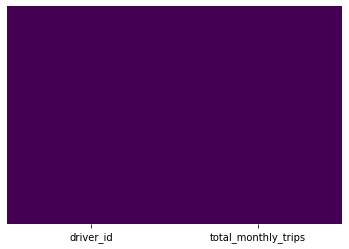

In [ ]:
#visual representation
sns.heatmap(df_completed.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [ ]:
df_ride.isnull().sum()

ride_id      0
driver_id    0
dtype: int64

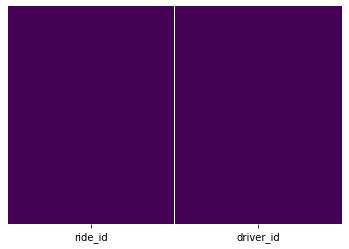

In [ ]:
#visual representation
sns.heatmap(df_ride.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [ ]:
df_request.isnull().sum()

day_of_week              0
Hour                     0
Minute                   0
ride_id                  0
passenger_id             0
driver_id                0
undiscounted_fare    49600
rating               78212
ride_duration        49586
ride_distance        49600
status                   0
dtype: int64

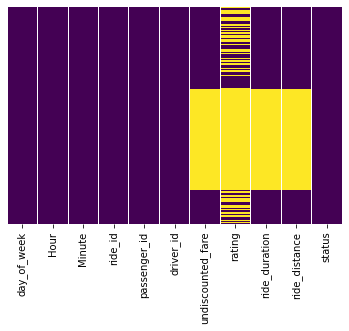

In [ ]:
#visual representation
sns.heatmap(df_request.isnull(),yticklabels=False,cbar=False,cmap='viridis')

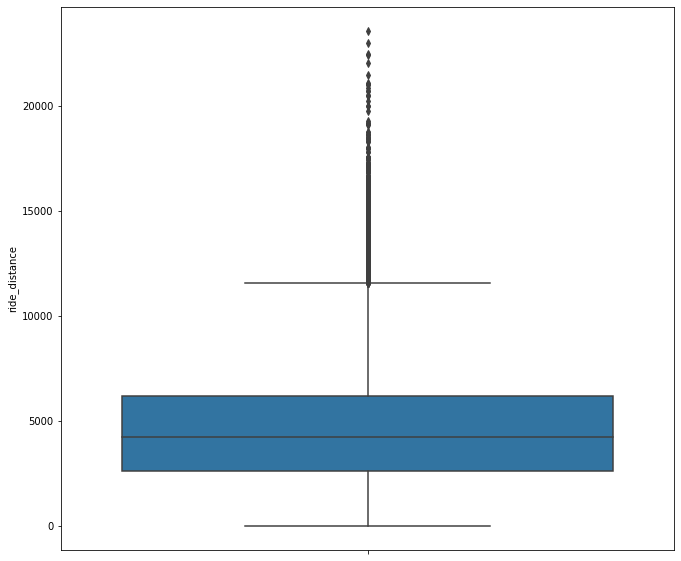

In [ ]:
fig, axes = plt.subplots(figsize=(11, 10), sharex=True)
sns.boxplot(data=df_request, y='ride_distance');

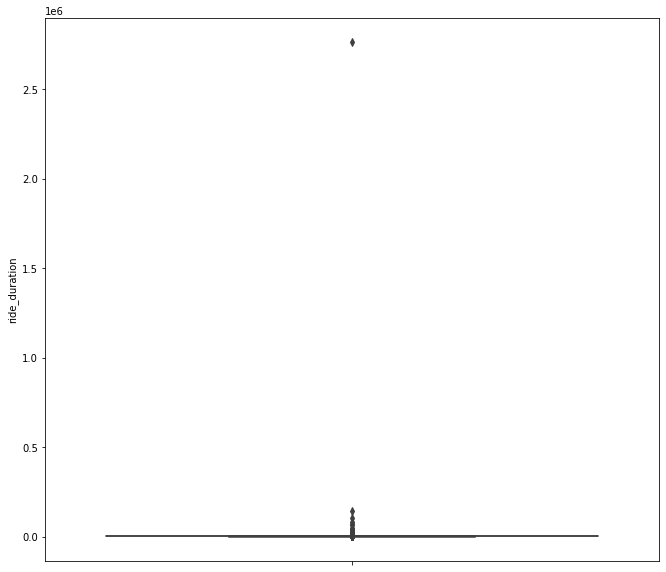

In [ ]:
fig, axes = plt.subplots(figsize=(11, 10), sharex=True)
sns.boxplot(data=df_request, y='ride_duration');

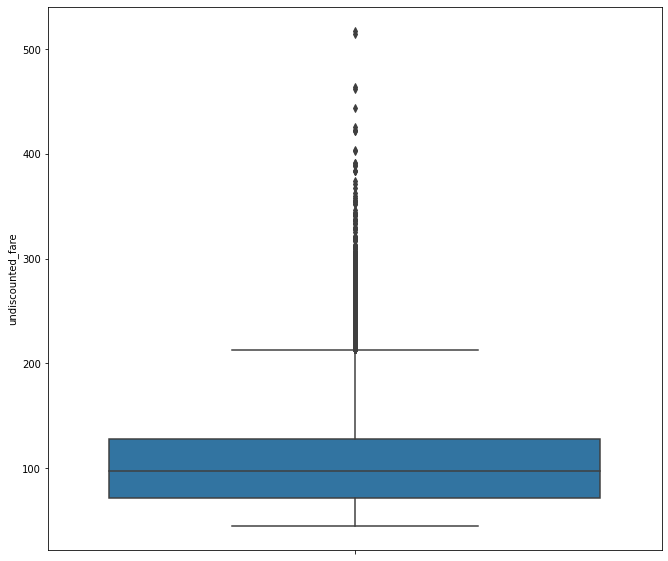

In [ ]:
fig, axes = plt.subplots(figsize=(11, 10), sharex=True)
sns.boxplot(data=df_request, y='undiscounted_fare');

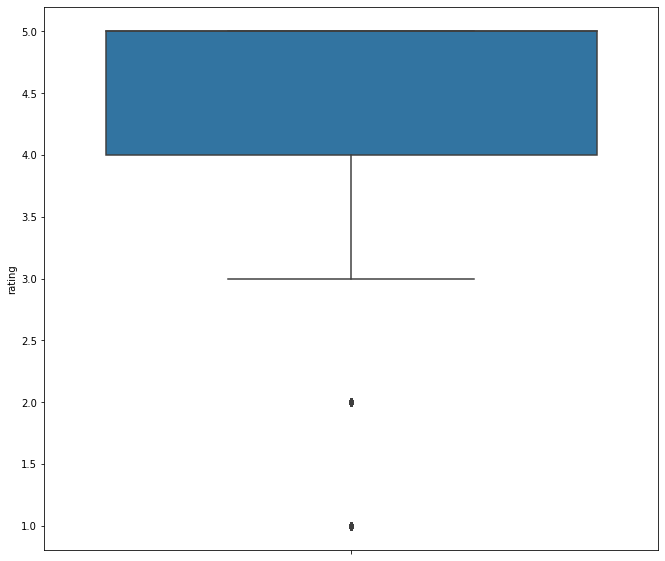

In [ ]:
fig, axes = plt.subplots(figsize=(11, 10), sharex=True)
sns.boxplot(data=df_request, y='rating');

In [ ]:
df_request['ride_distance'] = df_request['ride_distance'].fillna(df_request['ride_distance'].median())
df_request['ride_duration'] = df_request['ride_duration'].fillna(df_request['ride_duration'].mean())
df_request['undiscounted_fare'] = df_request['undiscounted_fare'].fillna(df_request['undiscounted_fare'].median())
df_request['rating'] = df_request['rating'].fillna(0)

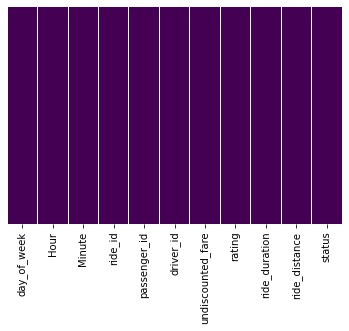

In [ ]:
#visual representation
sns.heatmap(df_request.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [ ]:
df_request.shape

(106139, 11)

In [ ]:
weekly_data=pd.merge(df_ride,df_request,on=['driver_id','ride_id'],how='left')

In [ ]:
weekly_data.head()

,ride_id,driver_id,day_of_week,Hour,Minute,passenger_id,undiscounted_fare,rating,ride_duration,ride_distance,status
0,78A5D3,4922405,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,78A5D3,5332197,1.0,5.0,2.0,4861945.0,97.0,0.0,996.124326,4241.0,CANCELED
2,78A604,5303157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,78A604,3355215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,78A604,5265495,1.0,5.0,54.0,4959579.0,97.0,0.0,996.124326,4241.0,CANCELED


In [ ]:
weekly_data.shape

(238559, 11)

In [ ]:
weekly_data.to_csv('/content/drive/My Drive/pathao_assignment/weekly_data.csv',index=False)

In [ ]:
weekly_data.isnull().sum()

ride_id                   0
driver_id                 0
day_of_week          149405
Hour                 149405
Minute               149405
passenger_id         149405
undiscounted_fare    149405
rating               149405
ride_duration        149405
ride_distance        149405
status               149405
dtype: int64

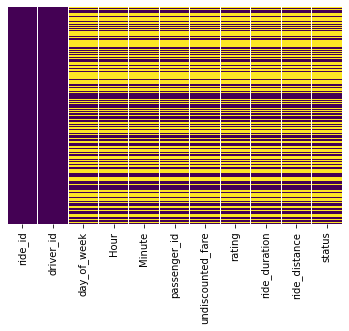

In [ ]:
#visual representation
sns.heatmap(weekly_data.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [ ]:
weekly_data=weekly_data.dropna()

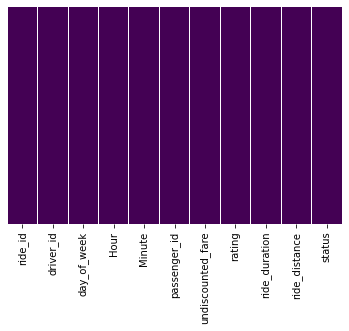

In [ ]:
#visual representation
sns.heatmap(weekly_data.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [ ]:
# weekly_data.loc[weekly_data['status'] >=0.5, 'status'] = 1
# weekly_data.loc[weekly_data['status'] <0.5, 'status'] = 0

In [ ]:
weekly_data.head()

,ride_id,driver_id,day_of_week,Hour,Minute,passenger_id,undiscounted_fare,rating,ride_duration,ride_distance,status
1,78A5D3,5332197,1.0,5.0,2.0,4861945.0,97.0,0.0,996.124326,4241.0,CANCELED
4,78A604,5265495,1.0,5.0,54.0,4959579.0,97.0,0.0,996.124326,4241.0,CANCELED
6,78A6T1,5169068,1.0,6.0,44.0,3718289.0,124.0,4.0,752.000000,6272.0,COMPLETED
8,78A76B,5374557,1.0,6.0,52.0,3435808.0,111.0,5.0,702.000000,5378.0,COMPLETED
10,78A76F,3810107,1.0,6.0,52.0,3700960.0,53.0,4.0,248.000000,1548.0,COMPLETED


(89154, 11)
COMPLETED    56538
CANCELED     32616
Name: status, dtype: int64
Class 1: 56538
Class 0: 32616
Proportion: 1.73 : 1


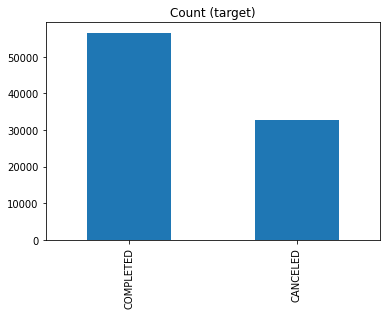

In [ ]:
print(weekly_data.shape)
target_count = weekly_data.status.value_counts()
print(target_count)
print('Class 1:', target_count["COMPLETED"])
print('Class 0:', target_count["CANCELED"])
print('Proportion:', round(target_count[0] / target_count[1], 2), ': 1')

target_count.plot(kind='bar', title='Count (target)');

### **Driver profiling Analysis**

In [ ]:
df_request['driver_id'].is_unique

False

In [ ]:
df_completed['driver_id'].is_unique

True

 **driver_ride_assignments.csv file contains the driver assignments for all requests in the
one week time period.**

###**Determining Request assign per driver**

In [ ]:
query1 = '''
            SELECT 
                driver_id,count(ride_id) as assign_ride
                      
            FROM 
                df_ride group by driver_id
            
        '''

output1 = pandasql.sqldf(query1, globals())

In [ ]:
print(output1)

      driver_id  assign_ride
0       2869108            1
1       2869204           99
2       2869278           11
3       2870173          285
4       2886584          189
...         ...          ...
3533    5441296            4
3534    5441518           10
3535    5441667            4
3536    5441669            4
3537    5441700            3

[3538 rows x 2 columns]


###**Determining Accepted request per driver:**

In [ ]:
query2 = '''
            SELECT 
                driver_id,count(ride_id) as accepted_ride
                      
            FROM 
                weekly_data group by driver_id
            
        '''

output2 = pandasql.sqldf(query2, globals())

In [ ]:
print(output2)

      driver_id  accepted_ride
0       2869204             47
1       2869278              3
2       2870173             49
3       2886584             58
4       2894871             63
...         ...            ...
2994    5441084              9
2995    5441296              3
2996    5441518              6
2997    5441667              1
2998    5441669              1

[2999 rows x 2 columns]


In [ ]:
query3 = '''
            SELECT output1.driver_id,output1.assign_ride,
            sum(case when output1.driver_id=output2.driver_id then output2.accepted_ride else 0 end) AS accepted_ride
            
            FROM output2,output1
            GROUP BY output1.driver_id
            
        '''

output3 = pandasql.sqldf(query3, globals())

In [ ]:
print(output3)

      driver_id  assign_ride  accepted_ride
0       2869108            1              0
1       2869204           99             47
2       2869278           11              3
3       2870173          285             49
4       2886584          189             58
...         ...          ...            ...
3533    5441296            4              3
3534    5441518           10              6
3535    5441667            4              1
3536    5441669            4              1
3537    5441700            3              0

[3538 rows x 3 columns]


In [ ]:
total_assign_request=list(output3['assign_ride'])
Unique_driver=list(output1['driver_id'])
total_accepted_request=list(output3['accepted_ride'])
print(total_assign_request)
print(len(total_assign_request))

[1, 99, 11, 285, 189, 131, 358, 118, 1, 13, 4, 9, 6, 12, 1, 27, 159, 9, 67, 26, 5, 144, 224, 3, 67, 5, 6, 10, 172, 14, 22, 127, 5, 6, 39, 17, 109, 3, 111, 314, 7, 24, 51, 1, 68, 24, 58, 178, 94, 5, 128, 20, 28, 264, 125, 1, 22, 6, 76, 190, 82, 57, 2, 38, 23, 8, 33, 143, 56, 2, 76, 29, 17, 167, 318, 42, 11, 25, 1, 13, 77, 30, 94, 1, 17, 3, 47, 1, 4, 14, 213, 25, 22, 55, 4, 2, 4, 87, 8, 40, 371, 1, 1, 31, 1, 83, 76, 208, 14, 129, 54, 29, 20, 110, 214, 58, 45, 64, 2, 12, 30, 30, 97, 70, 14, 7, 91, 9, 9, 368, 6, 107, 59, 8, 26, 336, 385, 1, 203, 3, 74, 3, 151, 1, 88, 60, 8, 14, 29, 20, 91, 147, 42, 38, 55, 1, 5, 3, 59, 1, 19, 19, 243, 56, 77, 43, 12, 97, 25, 1, 1, 173, 95, 69, 101, 4, 191, 55, 31, 240, 7, 55, 80, 2, 117, 55, 13, 69, 17, 80, 227, 30, 40, 55, 146, 48, 53, 18, 16, 66, 108, 71, 48, 1, 71, 38, 24, 11, 301, 44, 23, 29, 149, 14, 117, 1, 34, 4, 61, 45, 34, 144, 6, 155, 25, 5, 3, 82, 99, 35, 2, 3, 1, 1, 110, 162, 24, 102, 4, 138, 34, 67, 46, 34, 6, 16, 201, 29, 21, 1, 6, 104, 28, 4

In [ ]:
print(total_assign_request)
print(len(total_assign_request))

[1, 99, 11, 285, 189, 131, 358, 118, 1, 13, 4, 9, 6, 12, 1, 27, 159, 9, 67, 26, 5, 144, 224, 3, 67, 5, 6, 10, 172, 14, 22, 127, 5, 6, 39, 17, 109, 3, 111, 314, 7, 24, 51, 1, 68, 24, 58, 178, 94, 5, 128, 20, 28, 264, 125, 1, 22, 6, 76, 190, 82, 57, 2, 38, 23, 8, 33, 143, 56, 2, 76, 29, 17, 167, 318, 42, 11, 25, 1, 13, 77, 30, 94, 1, 17, 3, 47, 1, 4, 14, 213, 25, 22, 55, 4, 2, 4, 87, 8, 40, 371, 1, 1, 31, 1, 83, 76, 208, 14, 129, 54, 29, 20, 110, 214, 58, 45, 64, 2, 12, 30, 30, 97, 70, 14, 7, 91, 9, 9, 368, 6, 107, 59, 8, 26, 336, 385, 1, 203, 3, 74, 3, 151, 1, 88, 60, 8, 14, 29, 20, 91, 147, 42, 38, 55, 1, 5, 3, 59, 1, 19, 19, 243, 56, 77, 43, 12, 97, 25, 1, 1, 173, 95, 69, 101, 4, 191, 55, 31, 240, 7, 55, 80, 2, 117, 55, 13, 69, 17, 80, 227, 30, 40, 55, 146, 48, 53, 18, 16, 66, 108, 71, 48, 1, 71, 38, 24, 11, 301, 44, 23, 29, 149, 14, 117, 1, 34, 4, 61, 45, 34, 144, 6, 155, 25, 5, 3, 82, 99, 35, 2, 3, 1, 1, 110, 162, 24, 102, 4, 138, 34, 67, 46, 34, 6, 16, 201, 29, 21, 1, 6, 104, 28, 4

In [ ]:
print(total_accepted_request)
print(len(total_accepted_request))

[0, 47, 3, 49, 58, 63, 44, 96, 0, 0, 0, 1, 2, 2, 0, 15, 31, 2, 29, 13, 4, 73, 51, 0, 26, 1, 5, 5, 72, 2, 18, 14, 3, 0, 2, 5, 24, 1, 11, 16, 3, 0, 9, 0, 28, 2, 12, 51, 63, 0, 11, 1, 5, 62, 50, 0, 11, 0, 41, 68, 13, 8, 1, 15, 1, 6, 18, 81, 26, 0, 39, 3, 3, 63, 55, 8, 3, 4, 0, 1, 19, 5, 41, 0, 1, 0, 4, 0, 0, 7, 96, 6, 2, 11, 0, 0, 1, 41, 4, 15, 117, 0, 0, 3, 0, 10, 37, 45, 3, 36, 22, 9, 12, 43, 110, 28, 24, 0, 0, 0, 7, 1, 35, 26, 4, 6, 3, 9, 4, 25, 2, 45, 12, 0, 14, 110, 53, 0, 15, 2, 11, 0, 81, 0, 48, 10, 2, 13, 3, 0, 6, 37, 9, 19, 52, 0, 0, 0, 34, 1, 1, 10, 40, 9, 19, 23, 1, 39, 25, 0, 0, 63, 33, 13, 39, 0, 39, 19, 1, 43, 0, 40, 12, 0, 29, 18, 1, 27, 2, 41, 60, 4, 2, 8, 86, 11, 19, 0, 0, 37, 70, 14, 4, 0, 16, 21, 12, 5, 78, 5, 5, 0, 85, 3, 59, 0, 25, 0, 7, 13, 0, 71, 0, 70, 2, 1, 1, 20, 54, 31, 1, 0, 0, 1, 5, 11, 1, 35, 0, 27, 13, 32, 36, 6, 0, 1, 104, 20, 16, 0, 0, 69, 13, 20, 0, 43, 0, 24, 62, 9, 48, 3, 0, 12, 13, 54, 10, 1, 0, 0, 15, 2, 15, 0, 61, 36, 14, 11, 8, 2, 18, 0, 6, 0, 186, 

###**Determining Completed request per driver:**

In [ ]:
query4 = '''
            SELECT 
              driver_id,count(ride_id) as completed_trip
                      
            FROM 
            weekly_data 
            where status='COMPLETED'
            group by driver_id 
            
        '''

output4 = pandasql.sqldf(query4, globals())

In [ ]:
print(output4)

      driver_id  completed_trip
0       2869204              40
1       2870173              19
2       2886584              53
3       2894871              37
4       2894948              33
...         ...             ...
2770    5440699               5
2771    5441084               8
2772    5441296               3
2773    5441518               4
2774    5441667               1

[2775 rows x 2 columns]


In [ ]:
query5 = '''
            SELECT output1.driver_id,output1.assign_ride,
            sum(case when output1.driver_id=output4.driver_id then output4.completed_trip else 0 end) AS completed_ride
            
            FROM output4,output1
            GROUP BY output1.driver_id
            
        '''

output5 = pandasql.sqldf(query5, globals())

In [ ]:
print(output5)

      driver_id  assign_ride  completed_ride
0       2869108            1               0
1       2869204           99              40
2       2869278           11               0
3       2870173          285              19
4       2886584          189              53
...         ...          ...             ...
3533    5441296            4               3
3534    5441518           10               4
3535    5441667            4               1
3536    5441669            4               0
3537    5441700            3               0

[3538 rows x 3 columns]


In [ ]:
total_completed_trips= list(output5['completed_ride'])
print(total_completed_trips)
print(len(total_completed_trips))

[0, 40, 0, 19, 53, 37, 33, 78, 0, 0, 0, 0, 1, 1, 0, 10, 15, 1, 14, 3, 4, 46, 33, 0, 8, 1, 5, 2, 41, 0, 15, 3, 0, 0, 1, 4, 21, 0, 5, 6, 2, 0, 5, 0, 25, 0, 3, 37, 50, 0, 8, 0, 2, 36, 37, 0, 10, 0, 29, 53, 13, 7, 1, 9, 0, 4, 8, 63, 18, 0, 13, 0, 0, 46, 16, 4, 3, 2, 0, 0, 16, 0, 8, 0, 1, 0, 1, 0, 0, 5, 50, 4, 0, 3, 0, 0, 0, 19, 3, 6, 50, 0, 0, 1, 0, 2, 25, 25, 2, 26, 21, 6, 3, 34, 93, 6, 21, 0, 0, 0, 2, 0, 2, 20, 2, 5, 3, 7, 1, 7, 2, 28, 6, 0, 3, 38, 24, 0, 3, 2, 2, 0, 38, 0, 28, 0, 0, 10, 1, 0, 2, 25, 8, 15, 28, 0, 0, 0, 27, 0, 1, 8, 1, 5, 7, 15, 0, 28, 24, 0, 0, 27, 3, 1, 20, 0, 13, 7, 0, 14, 0, 30, 3, 0, 16, 13, 0, 20, 1, 19, 33, 2, 2, 1, 38, 10, 10, 0, 0, 28, 38, 0, 2, 0, 6, 19, 7, 2, 48, 3, 4, 0, 72, 2, 42, 0, 21, 0, 1, 8, 0, 54, 0, 53, 1, 0, 0, 15, 36, 25, 0, 0, 0, 0, 0, 8, 0, 19, 0, 18, 2, 23, 26, 6, 0, 0, 35, 14, 12, 0, 0, 47, 11, 18, 0, 24, 0, 10, 43, 4, 36, 0, 0, 4, 10, 37, 5, 0, 0, 0, 10, 1, 9, 0, 46, 26, 12, 7, 1, 1, 8, 0, 2, 0, 97, 0, 5, 5, 81, 14, 90, 1, 0, 30, 13, 69, 36, 30

In [ ]:
total_cancelled_trips=[ (i - j ) for i, j in zip(total_accepted_request,total_completed_trips)]

In [ ]:
Acceptance_Rate = [ round(((i / j)*100 ), 2) for i, j in zip(total_accepted_request, total_assign_request)]

In [ ]:
print(max(Acceptance_Rate))

100.0


In [ ]:
Completion_Rate = [ round(((i / j)*100 ), 2) for i, j in zip(total_completed_trips, total_assign_request)]

In [ ]:
Cancellation_Rate = [ round(((i / j)*100 ), 2) for i, j in zip(total_cancelled_trips, total_assign_request)]

In [ ]:
query6 = '''
            SELECT 
                driver_id,round(avg(ride_distance),2) as avg_ride_distance
                      
            FROM 
                weekly_data group by driver_id
            
        '''

output6 = pandasql.sqldf(query6, globals())


In [ ]:
print(output6)

      driver_id  avg_ride_distance
0       2869204            4240.19
1       2869278            4241.00
2       2870173            4045.92
3       2886584            4949.07
4       2894871            4766.17
...         ...                ...
2994    5441084            4323.56
2995    5441296            8917.67
2996    5441518            4173.00
2997    5441667            5013.00
2998    5441669            4241.00

[2999 rows x 2 columns]


In [ ]:
query7 = '''
            SELECT output1.driver_id,
            sum(case when output1.driver_id=output6.driver_id then output6.avg_ride_distance else 0 end) AS avg_ride_distance
            
            FROM output6,output1
            GROUP BY output1.driver_id
            
        '''

output7 = pandasql.sqldf(query7, globals())


In [ ]:
print(output7)

      driver_id  avg_ride_distance
0       2869108               0.00
1       2869204            4240.19
2       2869278            4241.00
3       2870173            4045.92
4       2886584            4949.07
...         ...                ...
3533    5441296            8917.67
3534    5441518            4173.00
3535    5441667            5013.00
3536    5441669            4241.00
3537    5441700               0.00

[3538 rows x 2 columns]


In [ ]:
Average_ride_distance= list(output7['avg_ride_distance'])
print(Average_ride_distance)
print(len(Average_ride_distance))

[0.0, 4240.19, 4241.0, 4045.92, 4949.07, 4766.17, 5268.91, 4625.3, 0.0, 0.0, 0.0, 4241.0, 5233.0, 4729.5, 0.0, 5020.6, 4560.19, 6644.5, 4410.0, 4487.92, 3810.0, 4189.63, 4957.49, 0.0, 4405.23, 4571.0, 3715.8, 5139.6, 4767.49, 4241.0, 3986.61, 3940.86, 4241.0, 0.0, 6275.0, 6262.4, 6026.13, 4241.0, 3927.36, 4455.88, 1457.0, 0.0, 4214.11, 0.0, 4091.07, 4241.0, 3792.92, 4248.37, 4617.16, 0.0, 5307.18, 4241.0, 4940.2, 4036.68, 4062.12, 0.0, 4774.27, 0.0, 5081.54, 4467.74, 2974.62, 3367.5, 1936.0, 5056.6, 4241.0, 4837.5, 4917.28, 4295.63, 4712.0, 0.0, 3964.44, 4241.0, 4241.0, 4951.14, 4176.27, 3445.0, 6613.67, 4888.5, 0.0, 4241.0, 5263.47, 4241.0, 4362.76, 0.0, 107.0, 0.0, 4593.5, 0.0, 0.0, 3367.43, 4548.22, 4453.0, 4241.0, 4220.0, 0.0, 0.0, 4241.0, 4225.63, 3356.75, 4673.53, 4735.57, 0.0, 0.0, 3275.0, 0.0, 3880.4, 5099.59, 5158.67, 3728.0, 3827.22, 6362.41, 7219.44, 4471.33, 5049.91, 5045.48, 4064.5, 3979.0, 0.0, 0.0, 0.0, 3868.57, 4241.0, 4073.6, 4820.81, 4574.25, 5422.17, 5825.0, 5211.78,

In [ ]:
query8 = '''
            SELECT 
                driver_id,round(avg(ride_duration),2) as avg_ride_duration
                      
            FROM 
                weekly_data group by driver_id
            
        '''

output8 = pandasql.sqldf(query8, globals())
print(output6)

      driver_id  avg_ride_distance
0       2869204            4240.19
1       2869278            4241.00
2       2870173            4045.92
3       2886584            4949.07
4       2894871            4766.17
...         ...                ...
2994    5441084            4323.56
2995    5441296            8917.67
2996    5441518            4173.00
2997    5441667            5013.00
2998    5441669            4241.00

[2999 rows x 2 columns]


In [ ]:
query9 = '''
            SELECT output1.driver_id,
            sum(case when output1.driver_id=output8.driver_id then output8.avg_ride_duration else 0 end) AS avg_ride_duration
            
            FROM output8,output1
            GROUP BY output1.driver_id
            
        '''

output9 = pandasql.sqldf(query9, globals())
print(output9)

      driver_id  avg_ride_duration
0       2869108               0.00
1       2869204             892.51
2       2869278             996.12
3       2870173             904.40
4       2886584             865.65
...         ...                ...
3533    5441296            1333.00
3534    5441518             720.37
3535    5441667            2439.00
3536    5441669             996.12
3537    5441700               0.00

[3538 rows x 2 columns]


In [ ]:
Average_ride_duration= list(output9['avg_ride_duration'])
print(Average_ride_duration)
print(len(Average_ride_duration))

[0.0, 892.51, 996.12, 904.4, 865.65, 1001.88, 1089.71, 931.13, 0.0, 0.0, 0.0, 996.12, 1023.56, 1043.56, 0.0, 859.71, 1024.81, 1267.06, 914.06, 1094.17, 430.75, 936.22, 1150.0, 0.0, 941.82, 2079.0, 875.0, 1215.47, 929.69, 996.12, 859.58, 862.17, 996.12, 0.0, 1183.56, 1097.02, 1334.89, 996.12, 884.43, 1047.27, 666.71, 0.0, 782.28, 0.0, 767.44, 996.12, 818.51, 917.05, 1133.14, 0.0, 1065.4, 996.12, 1164.87, 757.57, 916.39, 0.0, 1419.1, 0.0, 1142.99, 1055.25, 643.31, 899.14, 470.0, 1088.05, 996.12, 928.87, 951.01, 824.02, 1054.88, 0.0, 869.88, 996.12, 996.12, 1113.22, 985.91, 784.06, 1490.67, 943.06, 0.0, 996.12, 1090.49, 996.12, 980.44, 0.0, 1538.0, 0.0, 1007.34, 0.0, 0.0, 753.04, 1012.96, 1158.87, 996.12, 1004.45, 0.0, 0.0, 996.12, 846.97, 705.28, 949.94, 996.53, 0.0, 0.0, 665.42, 0.0, 914.9, 936.01, 1037.74, 994.37, 775.92, 1286.23, 1456.04, 1097.68, 1067.56, 960.13, 894.27, 787.6, 0.0, 0.0, 0.0, 899.23, 996.12, 962.15, 815.41, 856.06, 1094.52, 1033.67, 1019.92, 747.59, 922.29, 1023.0, 8

In [ ]:
query10 = '''
            SELECT driver_id,
            sum(case when rating<>0 then 1 else 0 end) AS no_of_rating
            
            FROM weekly_data
            GROUP BY driver_id
            
        '''

output10 = pandasql.sqldf(query10, globals())
print(output10)

      driver_id  no_of_rating
0       2869204            21
1       2869278             0
2       2870173            12
3       2886584            33
4       2894871            15
...         ...           ...
2994    5441084             4
2995    5441296             1
2996    5441518             0
2997    5441667             0
2998    5441669             0

[2999 rows x 2 columns]


In [ ]:
query11 = '''
            SELECT output1.driver_id,
            sum(case when output1.driver_id=output10.driver_id then output10.no_of_rating else 0 end) AS no_of_rating
            
            FROM output10,output1
            GROUP BY output1.driver_id
            
        '''

output11 = pandasql.sqldf(query11, globals())
print(output11)

      driver_id  no_of_rating
0       2869108             0
1       2869204            21
2       2869278             0
3       2870173            12
4       2886584            33
...         ...           ...
3533    5441296             1
3534    5441518             0
3535    5441667             0
3536    5441669             0
3537    5441700             0

[3538 rows x 2 columns]


In [ ]:
No_getting_rating= list(output11['no_of_rating'])
print(No_getting_rating)
print(len(No_getting_rating))

[0, 21, 0, 12, 33, 15, 18, 31, 0, 0, 0, 0, 1, 0, 0, 6, 7, 1, 5, 2, 3, 24, 12, 0, 5, 0, 4, 1, 22, 0, 5, 1, 0, 0, 0, 2, 10, 0, 3, 5, 1, 0, 0, 0, 13, 0, 1, 19, 24, 0, 5, 0, 1, 17, 17, 0, 7, 0, 10, 26, 6, 2, 1, 6, 0, 2, 5, 33, 10, 0, 6, 0, 0, 27, 7, 1, 2, 1, 0, 0, 8, 0, 5, 0, 0, 0, 1, 0, 0, 1, 19, 3, 0, 2, 0, 0, 0, 6, 3, 3, 26, 0, 0, 0, 0, 1, 9, 14, 1, 17, 9, 4, 2, 22, 54, 3, 14, 0, 0, 0, 1, 0, 0, 12, 2, 3, 1, 4, 0, 3, 1, 14, 5, 0, 1, 19, 9, 0, 2, 2, 1, 0, 24, 0, 16, 0, 0, 5, 0, 0, 2, 14, 4, 5, 10, 0, 0, 0, 11, 0, 0, 3, 1, 2, 3, 8, 0, 9, 14, 0, 0, 15, 2, 0, 13, 0, 4, 1, 0, 6, 0, 19, 3, 0, 9, 8, 0, 9, 0, 10, 16, 0, 1, 1, 18, 5, 5, 0, 0, 19, 19, 0, 1, 0, 0, 12, 4, 0, 31, 1, 2, 0, 27, 1, 26, 0, 13, 0, 0, 5, 0, 27, 0, 29, 1, 0, 0, 5, 20, 13, 0, 0, 0, 0, 0, 5, 0, 13, 0, 11, 1, 10, 8, 2, 0, 0, 18, 7, 4, 0, 0, 29, 8, 8, 0, 12, 0, 3, 25, 2, 18, 0, 0, 1, 2, 26, 2, 0, 0, 0, 4, 1, 6, 0, 32, 14, 6, 4, 0, 1, 4, 0, 1, 0, 57, 0, 3, 5, 40, 6, 48, 1, 0, 10, 7, 32, 19, 16, 18, 0, 9, 11, 0, 6, 0, 2, 0, 7, 3,

In [ ]:
Getting_rating_rate = [ round(((i / j)*100 ), 2) for i, j in zip(No_of_Rating, total_assign_request)]

In [ ]:
|query12 = '''
            SELECT 
                driver_id,round(avg(undiscounted_fare),2) as avg_undiscounted_fare
                      
            FROM 
                weekly_data group by driver_id
            
        '''

output12 = pandasql.sqldf(query12, globals())
print(output12)

      driver_id  avg_undiscounted_fare
0       2869204                  95.40
1       2869278                  97.00
2       2870173                  94.00
3       2886584                 110.67
4       2894871                 104.68
...         ...                    ...
2994    5441084                  98.89
2995    5441296                 163.67
2996    5441518                  95.33
2997    5441667                 115.00
2998    5441669                  97.00

[2999 rows x 2 columns]


In [ ]:
query13 = '''
            SELECT output1.driver_id,
            sum(case when output1.driver_id=output12.driver_id then output12.avg_undiscounted_fare else 0 end) AS avg_undiscounted_fare
            
            FROM output12,output1
            GROUP BY output1.driver_id
            
        '''

output13 = pandasql.sqldf(query13, globals())
print(output13)

      driver_id  avg_undiscounted_fare
0       2869108                   0.00
1       2869204                  95.40
2       2869278                  97.00
3       2870173                  94.00
4       2886584                 110.67
...         ...                    ...
3533    5441296                 163.67
3534    5441518                  95.33
3535    5441667                 115.00
3536    5441669                  97.00
3537    5441700                   0.00

[3538 rows x 2 columns]


In [ ]:
Avg_undiscounted_fare= list(output13['avg_undiscounted_fare'])
print(Avg_undiscounted_fare)
print(len(Avg_undiscounted_fare))

[0.0, 95.4, 97.0, 94.0, 110.67, 104.68, 112.91, 103.36, 0.0, 0.0, 0.0, 97.0, 110.0, 102.5, 0.0, 106.4, 101.81, 133.5, 99.55, 101.62, 99.0, 96.89, 108.31, 0.0, 99.12, 99.0, 90.2, 111.4, 106.25, 97.0, 92.72, 93.71, 97.0, 0.0, 126.0, 127.8, 121.71, 97.0, 91.0, 101.25, 62.33, 0.0, 95.22, 0.0, 92.64, 97.0, 89.42, 96.47, 102.75, 0.0, 110.64, 97.0, 109.2, 96.03, 93.5, 0.0, 104.91, 0.0, 112.59, 99.35, 77.69, 81.88, 63.0, 109.27, 97.0, 110.0, 110.33, 98.2, 103.54, 0.0, 92.41, 97.0, 97.0, 109.76, 98.0, 87.0, 129.33, 105.0, 0.0, 97.0, 112.47, 97.0, 98.98, 0.0, 45.0, 0.0, 101.5, 0.0, 0.0, 89.43, 102.32, 99.0, 97.0, 97.45, 0.0, 0.0, 97.0, 97.17, 81.5, 102.2, 104.55, 0.0, 0.0, 81.33, 0.0, 92.4, 110.73, 111.93, 89.67, 88.92, 127.23, 141.22, 99.33, 111.21, 113.42, 94.43, 93.04, 0.0, 0.0, 0.0, 91.71, 97.0, 94.54, 109.23, 100.25, 115.0, 121.67, 109.0, 104.25, 97.44, 109.5, 94.78, 115.0, 0.0, 97.14, 94.15, 87.02, 0.0, 91.47, 151.0, 108.36, 0.0, 93.77, 0.0, 109.4, 97.0, 97.0, 103.77, 104.0, 0.0, 107.67, 1

In [ ]:
query14 = '''
            SELECT output1.driver_id,
            sum(case when output1.driver_id=df_completed.driver_id then df_completed.total_monthly_trips else 0 end) AS total_monthly_trips
            
            FROM df_completed,output1
            GROUP BY output1.driver_id
            
            
        '''

output14 = pandasql.sqldf(query14, globals())
print(output14)

      driver_id  total_monthly_trips
0       2869108                    0
1       2869204                  217
2       2869278                   21
3       2870173                   59
4       2886584                  151
...         ...                  ...
3533    5441296                    9
3534    5441518                  102
3535    5441667                   14
3536    5441669                    0
3537    5441700                    0

[3538 rows x 2 columns]


In [ ]:
target_label= list(output14['total_monthly_trips'])

In [ ]:


raw_data ={
            'Driver_ID': Unique_driver,
            'Total_Assigned_Requests':total_assign_request,
            'Total_Accepted_Requests': total_accepted_request,
            'Total_Completed_Trips':total_completed_trips,
            'Total_Cancelled_Trips':total_cancelled_trips,
            'Acceptance_Rate':Acceptance_Rate,
            'Completion_Rate':Completion_Rate,
            'Cancellation_Rate':Cancellation_Rate,
            'Average_Ride_Distance' : Average_ride_distance,
            'Average_Undiscounted_Fare': Avg_undiscounted_fare,
            'Average_Ride_Duration': Average_ride_duration,
            'No_Getting_Rating': No_getting_rating,
            'Getting_Rating_Rate':Getting_rating_rate,
            'Total_Trip': target_label
            }
df_performance=pd.DataFrame(raw_data,columns=['Driver_ID','Total_Assigned_Requests','Total_Accepted_Requests','Total_Completed_Trips','Total_Cancelled_Trips',
                                              'Acceptance_Rate','Completion_Rate','Cancellation_Rate','Average_Ride_Distance','Average_Undiscounted_Fare',
                                              'Average_Ride_Duration','No_Getting_Rating','Getting_Rating_Rate','Total_Trip'])


In [ ]:
print(df_performance)
print("ok")

      Driver_ID  Total_Assigned_Requests  Total_Accepted_Requests  \
0       2869108                        1                        0   
1       2869204                       99                       47   
2       2869278                       11                        3   
3       2870173                      285                       49   
4       2886584                      189                       58   
...         ...                      ...                      ...   
3533    5441296                        4                        3   
3534    5441518                       10                        6   
3535    5441667                        4                        1   
3536    5441669                        4                        1   
3537    5441700                        3                        0   

      Total_Completed_Trips  Total_Cancelled_Trips  Acceptance_Rate  \
0                         0                      0             0.00   
1                        40  

In [ ]:
df_performance.to_csv('/content/drive/My Drive/pathao_assignment/Driver_Profilling_Dataset.csv',index=False)
print(df_performance)
print("ok")

      Driver_ID  Total_Assigned_Requests  Total_Accepted_Requests  \
0       2869108                        1                        0   
1       2869204                       99                       47   
2       2869278                       11                        3   
3       2870173                      285                       49   
4       2886584                      189                       58   
...         ...                      ...                      ...   
3533    5441296                        4                        3   
3534    5441518                       10                        6   
3535    5441667                        4                        1   
3536    5441669                        4                        1   
3537    5441700                        3                        0   

      Total_Completed_Trips  Total_Cancelled_Trips  Acceptance_Rate  \
0                         0                      0             0.00   
1                        40  

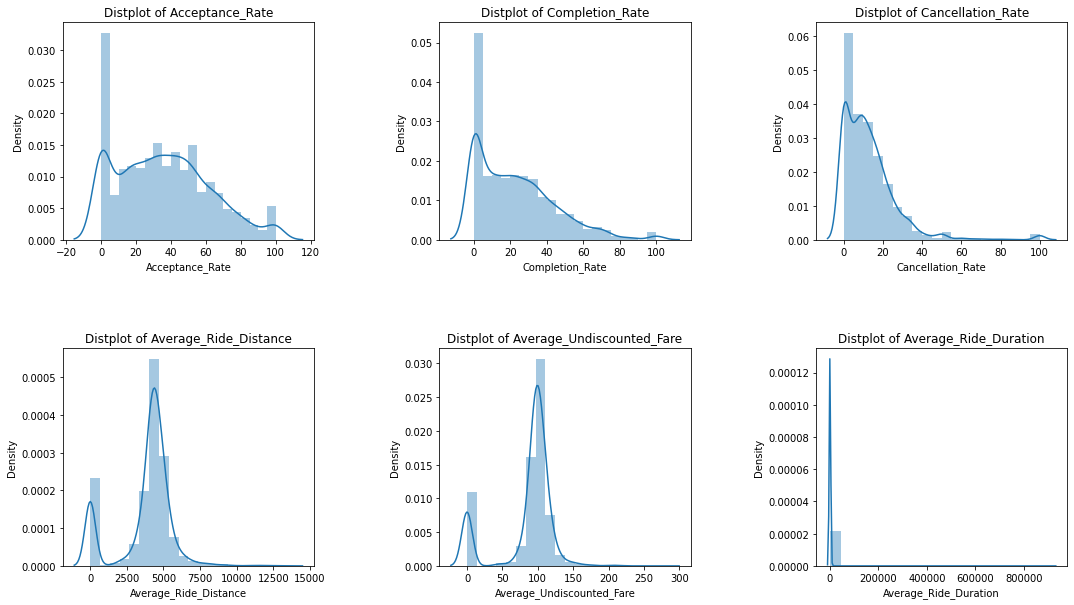

In [ ]:
plt.figure(1,figsize=(18,10))
n=0
for i in ['Acceptance_Rate','Completion_Rate','Cancellation_Rate','Average_Ride_Distance','Average_Undiscounted_Fare',
                                              'Average_Ride_Duration']:
    n+=1
    plt.subplot(2,3,n)
    plt.subplots_adjust(hspace=0.5,wspace=0.5)
    sns.distplot(df_performance[i],bins=20)
    plt.title('Distplot of {}'.format(i))
plt.show()

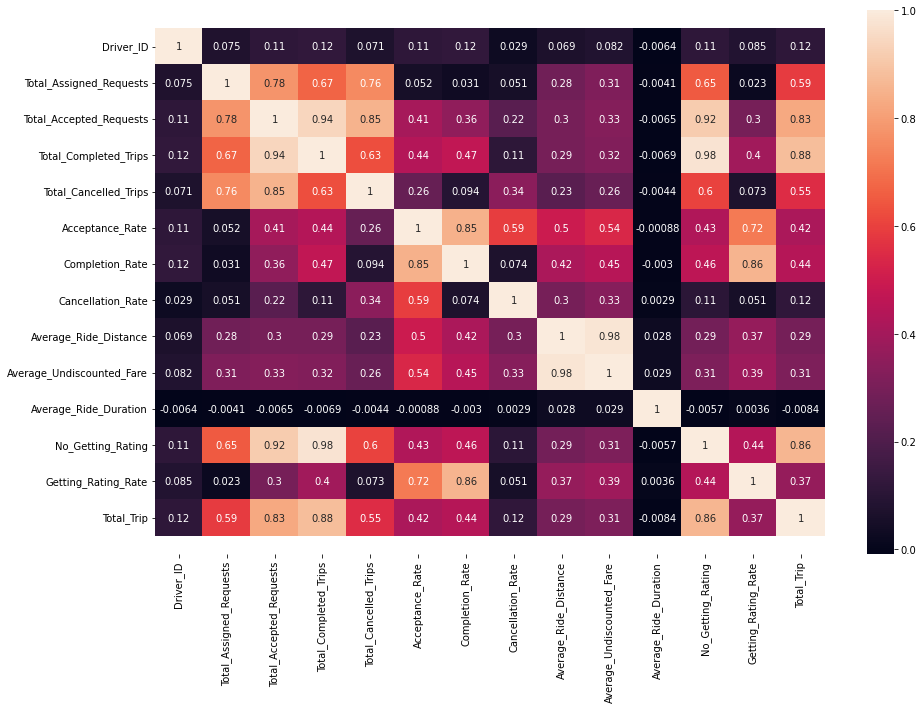

In [ ]:

fig, axes = plt.subplots(figsize=(15, 10), sharex=True)
ax=sns.heatmap(df_performance.corr(),annot=True)
bottom,top=ax.get_ylim()
ax.set_ylim(bottom+0.5,top-0.5)
plt.show()

In [ ]:
df_performance[df_performance.columns[:]].corr()['Total_Trip'][:]

Driver_ID                    0.116670
Total_Assigned_Requests      0.589726
Total_Accepted_Requests      0.827188
Total_Completed_Trips        0.878450
Total_Cancelled_Trips        0.551859
Acceptance_Rate              0.419647
Completion_Rate              0.441462
Cancellation_Rate            0.118367
Average_Ride_Distance        0.293356
Average_Undiscounted_Fare    0.313761
Average_Ride_Duration       -0.008368
No_Getting_Rating            0.861630
Getting_Rating_Rate          0.369636
Total_Trip                   1.000000
Name: Total_Trip, dtype: float64

### **Observations:**

* By observing the multivariate analysis from the heapmap() we see that the distribution of the metrics are not normal and there existslots of outliers in the dataset.
*	The correlation between Average ride distance and number of total trip for a particular driver id is negative, which means if the ride distance is small then the possibility of monthly total trip for a driver is high.
*	The correlation between Average ride duration and number of total trip for a particular driver id is negative, which means if the ride duration is low then the possibility of monthly total trip for a driver is high. 
* 	Assignment to completion ratio and Total trip is positive. For obvious reason if the completion ratio is high then the total trip count end of the month will also be high. 

## **Thank You..!**

### **Based on the profiles you developed can you design a way to tag good and bad drivers?**


In [ ]:
df_performance.describe()

,Driver_ID,Total_Assigned_Requests,Total_Accepted_Requests,Total_Completed_Trips,Total_Cancelled_Trips,Acceptance_Rate,Completion_Rate,Cancellation_Rate,Average_Ride_Distance,Average_Undiscounted_Fare,Average_Ride_Duration,No_Getting_Rating,Getting_Rating_Rate,Total_Trip
count,3.538000e+03,3538.000000,3538.000000,3538.000000,3538.000000,3538.000000,3538.000000,3538.000000,3538.000000,3538.000000,3538.000000,3538.000000,3538.000000,3538.000000
mean,4.778928e+06,67.427643,25.198982,15.980215,9.218768,35.820071,22.952979,12.867029,3804.104992,85.841962,1115.726393,7.893443,11.388282,70.961278
std,6.324610e+05,76.450612,29.862695,19.989569,12.942105,26.232294,21.185332,13.989072,1866.849645,39.034369,15548.244208,10.157688,12.442675,83.111395
min,2.869108e+06,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.463529e+06,11.000000,2.000000,1.000000,1.000000,14.470000,4.000000,3.120000,3649.830000,88.877500,772.620000,0.000000,0.000000,9.000000
50%,5.006205e+06,42.000000,14.000000,8.000000,4.500000,33.915000,19.375000,10.195000,4241.000000,97.220000,941.095000,4.000000,8.950000,40.000000
75%,5.286508e+06,98.000000,38.000000,25.000000,13.000000,53.330000,35.552500,17.960000,4766.127500,105.430000,1028.317500,12.000000,17.650000,106.000000
max,5.441700e+06,669.000000,225.000000,155.000000,183.000000,100.000000,100.000000,100.000000,13405.000000,277.000000,921706.750000,72.000000,100.000000,620.000000


In [ ]:
y = df_performance['Driver_ID']

In [ ]:
X = df_performance[['Completion_Rate','Getting_Rating_Rate','Total_Trip']]
X.head

<bound method NDFrame.head of       Completion_Rate  Getting_Rating_Rate  Total_Trip
0                0.00                 0.00           0
1               40.40                21.21         217
2                0.00                 0.00          21
3                6.67                 4.21          59
4               28.04                17.46         151
...               ...                  ...         ...
3533            75.00                25.00           9
3534            40.00                 0.00         102
3535            25.00                 0.00          14
3536             0.00                 0.00           0
3537             0.00                 0.00           0

[3538 rows x 3 columns]>

### **Feature Scaling**

In [ ]:
cols = X.columns

In [ ]:
# # Set the Numbers
# from scipy import stats
# customers_fix = pd.DataFrame()
# customers_fix["Completion_Rate"] = stats.boxcox(X['Completion_Rate'])[0]
# customers_fix["Getting_Rating_Rate"] = stats.boxcox(X['Getting_Rating_Rate'])[0]
# customers_fix["Total_Trip"] = pd.Series(np.cbrt(X['Total_Trip'])).values
# customers_fix.tail()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_normalized = scaler.transform(X)
print(X_normalized.mean(axis = 0).round(2))
print(X_normalized.std(axis = 0).round(2))

[-0.  0.  0.]
[1. 1. 1.]


In [ ]:
pd.DataFrame(X_normalized).head()

,0,1,2
0,-1.083590,-0.915389,-0.853930
1,0.823659,0.789469,1.757393
2,-1.083590,-0.915389,-0.601221
3,-0.768705,-0.576990,-0.143939
4,0.240154,0.488044,0.963166


### **Use elbow method to find optimal number of clusters**

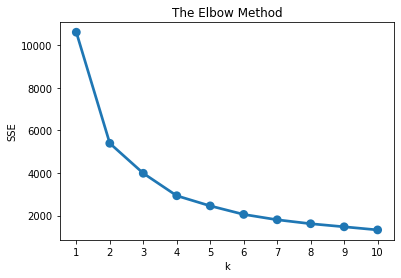

In [ ]:
from sklearn.cluster import KMeans

sse = {}
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_normalized)
    sse[k] = kmeans.inertia_ # SSE to closest cluster centroid

plt.title('The Elbow Method')
plt.xlabel('k')
plt.ylabel('SSE')
sns.pointplot(x=list(sse.keys()), y=list(sse.values()))
plt.show()

In [ ]:
model = KMeans(n_clusters=3, random_state=42)
model.fit(X_normalized)
model.labels_.shape

(3538,)

In [ ]:
X.shape

(3538, 3)

### **Cluster Analysis**

In [ ]:
X["Cluster"] = model.labels_
X.head()

,Completion_Rate,Getting_Rating_Rate,Total_Trip,Cluster
0,0.00,0.00,0,1
1,40.40,21.21,217,2
2,0.00,0.00,21,1
3,6.67,4.21,59,1
4,28.04,17.46,151,2


In [ ]:
# get centroids
centroids = kmeans.cluster_centers_
cen_x = [i[0] for i in centroids] 
cen_y = [i[1] for i in centroids]
## add to df
X['cen_x'] = X.Cluster.map({0:cen_x[0], 1:cen_x[1], 2:cen_x[2]})
X['cen_y'] = X.Cluster.map({0:cen_y[0], 1:cen_y[1], 2:cen_y[2]})
# define and map colors
colors = ['#DF2020', '#81DF20', '#2095DF']
X['c'] = X.Cluster.map({0:colors[0], 1:colors[1], 2:colors[2]})

In [ ]:
X.groupby('Cluster').agg({
    'Completion_Rate':'mean',
    'Getting_Rating_Rate':'mean',
    'Total_Trip':'mean'}).round(1)

,Completion_Rate,Getting_Rating_Rate,Total_Trip
Cluster,,,
0,50.8,27.4,62.9
1,9.6,4.1,28.9
2,34.6,16.9,201.1


### **Snake Plots**

In [ ]:
df_normalized = pd.DataFrame(X_normalized, columns=['Completion_Rate', 'Getting_rating_Rate', 'Total_Trip'])
df_normalized['ID'] = X.index
df_normalized['Cluster'] = model.labels_
df_normalized.head()

,Completion_Rate,Getting_rating_Rate,Total_Trip,ID,Cluster
0,-1.083590,-0.915389,-0.853930,0,1
1,0.823659,0.789469,1.757393,1,2
2,-1.083590,-0.915389,-0.601221,2,1
3,-0.768705,-0.576990,-0.143939,3,1
4,0.240154,0.488044,0.963166,4,2


In [ ]:
# Melt The Data
df_nor_melt = pd.melt(df_normalized.reset_index(),
                      id_vars=['Cluster'],
                      value_vars=['Completion_Rate','Getting_rating_Rate','Total_Trip'],
                      var_name='Attribute',
                      value_name='Value')
df_nor_melt.head()

,Cluster,Attribute,Value
0,1,Completion_Rate,-1.083590
1,2,Completion_Rate,0.823659
2,1,Completion_Rate,-1.083590
3,1,Completion_Rate,-0.768705
4,2,Completion_Rate,0.240154


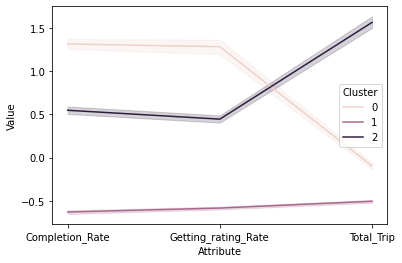

In [ ]:
sns.lineplot('Attribute', 'Value', hue='Cluster', data=df_nor_melt)

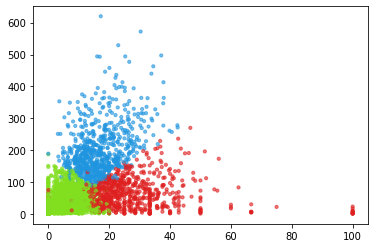

In [ ]:
plt.scatter(X.Getting_Rating_Rate, X.Total_Trip, c=X.c, alpha = 0.6, s=10)

(0.0, 200.0)

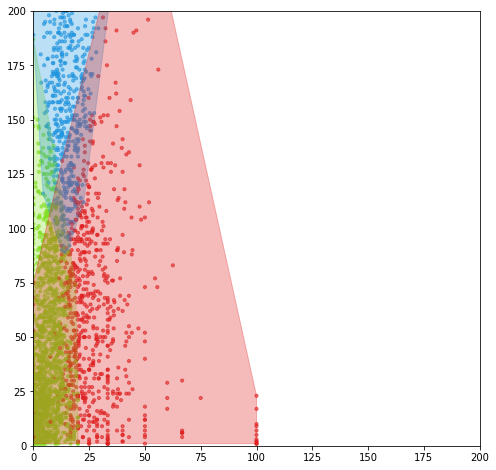

In [ ]:
from scipy.spatial import ConvexHull
import numpy as np
fig, ax = plt.subplots(1, figsize=(8,8))
# plot data
plt.scatter(X.Getting_Rating_Rate, X.Total_Trip, c=X.c, alpha = 0.6, s=10)
# # plot centers
# plt.scatter(cen_x, cen_y, marker='^', c=colors, s=70)
# draw enclosure
for i in X.Cluster.unique():
    points = X[X.Cluster == i][['Getting_Rating_Rate', 'Total_Trip']].values
    # get convex hull
    hull = ConvexHull(points)
    # get x and y coordinates
    # repeat last point to close the polygon
    x_hull = np.append(points[hull.vertices,0],
                       points[hull.vertices,0][0])
    y_hull = np.append(points[hull.vertices,1],
                       points[hull.vertices,1][0])
    # plot shape
    plt.fill(x_hull, y_hull, alpha=0.3, c=colors[i])
    
plt.xlim(0,200)
plt.ylim(0,200)

By using this plot and the summarized table it can be inferred that,
- cluster 0 have drivers whose completion rate is high, assignment to getting rating rate is high and total completed trip is also high.
- cluster 0 have drivers whose completion rate is lowest, assignment to getting rating rate is is also low and total completed trip is also very low.
- Finally, cluster 2 have drivers whose completion rate is higher than cluster 1 and lower than cluster 0, assignment to getting rating rate isis higher than cluster 1 and lower than cluster 0 but total completed trip is higher than both cluster 0 and cluster 1.